In [2]:
import pandas as pd

df = pd.read_csv("ir_coaching_gpt1_1000.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ir_coaching_gpt1_1000.csv'

In [3]:
import pandas as pd

df = pd.read_excel("ir_coaching_gpt1_1000.xlsx")
df.head()

,id,stage,sentence_type,text
0,1,문제 정의,설명형,문제 정의 단계에서는 핵심 고객을 중심으로 문제가 발생하는 구체적인 상황을 설명해야...
1,2,문제 정의,설명형,문제 정의 단계에서는 초기 고객을 중심으로 기존 방식이 실패하는 지점을 설명해야 합니다.
2,3,문제 정의,설명형,문제 정의 단계에서는 반복적으로 불편을 겪는 사용자를 중심으로 고객이 포기하거나 우...
3,4,문제 정의,설명형,문제 정의 단계에서는 문제를 가장 강하게 느끼는 사람을 중심으로 불편이 반복되는 순...
4,5,문제 정의,설명형,문제 정의 단계에서는 현재 대안을 사용 중인 고객을 중심으로 시간이나 비용이 낭비되...


In [4]:
texts = df["text"].astype(str).tolist()

print("문장 수:", len(texts))
print(texts[:3])

문장 수: 1000
['문제 정의 단계에서는 핵심 고객을 중심으로 문제가 발생하는 구체적인 상황을 설명해야 합니다.', '문제 정의 단계에서는 초기 고객을 중심으로 기존 방식이 실패하는 지점을 설명해야 합니다.', '문제 정의 단계에서는 반복적으로 불편을 겪는 사용자를 중심으로 고객이 포기하거나 우회하는 행동을 설명해야 합니다.']


In [6]:
%pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 33.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 73.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/19 [libclang]
    Found existing installation: protobuf 5.29.3━━━━━━━━━━━━━━━━━━  5/19 [protobuf]
    Uninstalling protobuf-5.29.3:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  5/19 [protobuf]
      Successfully uninstalled protobuf-5.29.3━━━━━━━━━━━━━━━━━━━━  5/19 [protobuf]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [tensorflow]9 [tensorflow]-py]
Note: you may need to restart the kernel to use updated packages.


In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 단어 사전 만들기
tokenizer = Tokenizer(oov_token="<UNK>")
tokenizer.fit_on_texts(texts)

# 문장을 숫자 시퀀스로 변환
sequences = tokenizer.texts_to_sequences(texts)

vocab_size = len(tokenizer.word_index) + 1

print("단어 사전 크기:", vocab_size)
print("첫 번째 원문:", texts[0])
print("첫 번째 숫자 시퀀스:", sequences[0])

I0000 00:00:1782195242.468778      87 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782195242.564652      87 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782195245.886395      87 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


단어 사전 크기: 791
첫 번째 원문: 문제 정의 단계에서는 핵심 고객을 중심으로 문제가 발생하는 구체적인 상황을 설명해야 합니다.
첫 번째 숫자 시퀀스: [31, 44, 59, 25, 47, 13, 187, 188, 42, 358, 60, 14]


In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 가장 긴 문장 길이 확인
max_length = max(len(seq) for seq in sequences)

# 모든 문장을 같은 길이로 맞추기
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

# 입력: 마지막 토큰 제외
X = padded_sequences[:, :-1]

# 정답: 첫 토큰 제외
y = padded_sequences[:, 1:]

print("최대 문장 길이:", max_length)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("첫 번째 입력:", X[0])
print("첫 번째 정답:", y[0])

최대 문장 길이: 18
X shape: (1000, 17)
y shape: (1000, 17)
첫 번째 입력: [ 31  44  59  25  47  13 187 188  42 358  60  14   0   0   0   0   0]
첫 번째 정답: [ 44  59  25  47  13 187 188  42 358  60  14   0   0   0   0   0   0]


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model


# 1. 토큰 임베딩 + 위치 임베딩
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_length, vocab_size, embed_dim):
        super().__init__()

        self.token_embedding = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim
        )

        self.position_embedding = layers.Embedding(
            input_dim=max_length,
            output_dim=embed_dim
        )

    def call(self, inputs):
        sequence_length = tf.shape(inputs)[-1]

        positions = tf.range(
            start=0,
            limit=sequence_length,
            delta=1
        )

        token_vectors = self.token_embedding(inputs)
        position_vectors = self.position_embedding(positions)

        return token_vectors + position_vectors


# 2. GPT Transformer Decoder 블록
class GPTBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )

        self.feed_forward = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim)
        ])

        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):

        # 미래 토큰을 보지 못하게 하는 Causal Mask
        attention_output = self.attention(
            query=inputs,
            value=inputs,
            key=inputs,
            use_causal_mask=True
        )

        attention_output = self.dropout1(
            attention_output,
            training=training
        )

        # Add & Norm
        output1 = self.layer_norm1(
            inputs + attention_output
        )

        # Feed Forward
        feed_forward_output = self.feed_forward(output1)

        feed_forward_output = self.dropout2(
            feed_forward_output,
            training=training
        )

        # Add & Norm
        return self.layer_norm2(
            output1 + feed_forward_output
        )

In [10]:
sequence_length = X.shape[1]
embed_dim = 128
num_heads = 4
ff_dim = 256
num_blocks = 2

inputs = layers.Input(
    shape=(sequence_length,),
    dtype=tf.int32
)

x = TokenAndPositionEmbedding(
    max_length=sequence_length,
    vocab_size=vocab_size,
    embed_dim=embed_dim
)(inputs)

for _ in range(num_blocks):
    x = GPTBlock(
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim
    )(x)

outputs = layers.Dense(
    vocab_size,
    activation="softmax"
)(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

E0000 00:00:1782195552.546921      87 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782195552.589926      87 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 17, 128)        │       103,424 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block (GPTBlock)            │ (None, 17, 128)        │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block_1 (GPTBlock)          │ (None, 17, 128)        │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 17, 791)        │       102,039 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,423 (1.79 MB)

 Trainable params: 470,423 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X,
    y,
    batch_size=32,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 0.4438 - loss: 4.0670 - val_accuracy: 0.6132 - val_loss: 3.2422
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.7132 - loss: 2.1408 - val_accuracy: 0.6297 - val_loss: 2.6603
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.7805 - loss: 1.3585 - val_accuracy: 0.6465 - val_loss: 2.5119
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.8064 - loss: 0.9788 - val_accuracy: 0.6612 - val_loss: 2.4615
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.8262 - loss: 0.7691 - val_accuracy: 0.6732 - val_loss: 2.4244
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.8394 - loss: 0.6453 - val_accuracy: 0.6774 - val_loss: 2.4196
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.8519 - loss: 0.5630 - val_accuracy: 0.6838 - val_loss: 2.4267
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8647 - loss: 0.5059 - val_accuracy: 0

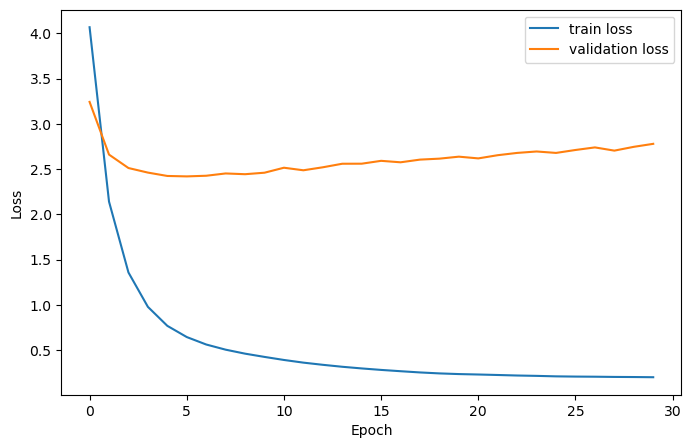

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

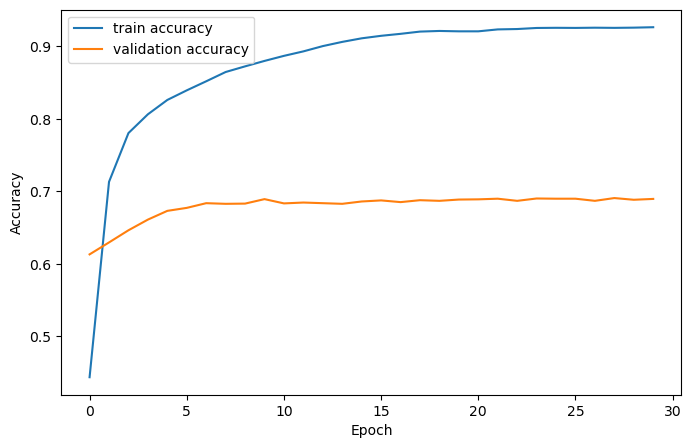

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [14]:
def generate_text(prompt, max_new_tokens=12):
    generated_text = prompt

    for _ in range(max_new_tokens):
        # 현재 문장을 숫자 시퀀스로 변환
        sequence = tokenizer.texts_to_sequences([generated_text])[0]

        # 모델 입력 길이 17에 맞춤
        sequence = pad_sequences(
            [sequence],
            maxlen=sequence_length,
            padding="post",
            truncating="pre"
        )

        # 각 위치의 다음 토큰 확률 예측
        predictions = model.predict(sequence, verbose=0)

        # 현재 문장의 마지막 실제 토큰 위치
        current_length = min(
            len(tokenizer.texts_to_sequences([generated_text])[0]),
            sequence_length
        )

        # 다음 토큰 확률
        next_token_probs = predictions[0, current_length - 1]

        # 확률이 가장 높은 토큰 선택
        next_token_id = int(np.argmax(next_token_probs))

        # 토큰 번호를 단어로 변환
        next_word = tokenizer.index_word.get(next_token_id)

        # 종료 조건
        if next_word is None or next_token_id == 0:
            break

        generated_text += " " + next_word

    return generated_text

In [15]:
print(generate_text("문제 정의 단계에서는"))
print(generate_text("다음으로 해야 할 일은"))
print(generate_text("경쟁사가 없습니다"))

문제 정의 단계에서는 초기 고객을 중심으로 기존 방식이 실패하는 지점을 설명해야 합니다
다음으로 해야 할 일은 고객이 거쳐야 하는 단계를 설명해야 합니다
경쟁사가 없습니다 전환을 망설이는 이유를 실제 사례로 보여줄 수 있나요


In [16]:
print(generate_text("문제 정의"))

문제 정의 내용이 기능 소개에 치우쳐 있습니다 발생 빈도가 어떻게 달라지는지 보여주세요


In [17]:
print(generate_text("문제 정의"))

문제 정의 내용이 기능 소개에 치우쳐 있습니다 발생 빈도가 어떻게 달라지는지 보여주세요


In [18]:
print(generate_text("문제 정의"))

문제 정의 내용이 기능 소개에 치우쳐 있습니다 발생 빈도가 어떻게 달라지는지 보여주세요


In [20]:
df = pd.read_csv("ir_coaching_merged_2000.csv")
texts = df["text"].astype(str).tolist()

print("문장 수:", len(texts))

문장 수: 2000


In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 2,000개 문장으로 단어 사전 다시 만들기
tokenizer = Tokenizer(oov_token="<UNK>")
tokenizer.fit_on_texts(texts)

# 문장을 숫자 시퀀스로 변환
sequences = tokenizer.texts_to_sequences(texts)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(seq) for seq in sequences)

# 길이 맞추기
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

# 다음 토큰 예측용 입력과 정답
X = padded_sequences[:, :-1]
y = padded_sequences[:, 1:]

print("문장 수:", len(texts))
print("단어 사전 크기:", vocab_size)
print("최대 문장 길이:", max_length)
print("X shape:", X.shape)
print("y shape:", y.shape)

문장 수: 2000
단어 사전 크기: 1713
최대 문장 길이: 31
X shape: (2000, 30)
y shape: (2000, 30)


In [22]:
sequence_length = X.shape[1]   # 30
embed_dim = 128
num_heads = 4
ff_dim = 256
num_blocks = 2

inputs = layers.Input(
    shape=(sequence_length,),
    dtype=tf.int32
)

x = TokenAndPositionEmbedding(
    max_length=sequence_length,
    vocab_size=vocab_size,
    embed_dim=embed_dim
)(inputs)

for _ in range(num_blocks):
    x = GPTBlock(
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim
    )(x)

outputs = layers.Dense(
    vocab_size,
    activation="softmax"
)(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 30, 128)        │       223,104 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block_2 (GPTBlock)          │ (None, 30, 128)        │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block_3 (GPTBlock)          │ (None, 30, 128)        │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30, 1713)       │       220,977 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709,041 (2.70 MB)

 Trainable params: 709,041 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X,
    y,
    batch_size=32,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.5951 - loss: 3.5105 - val_accuracy: 0.5758 - val_loss: 3.2683
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.7714 - loss: 1.5694 - val_accuracy: 0.6234 - val_loss: 2.8157
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.8226 - loss: 1.0091 - val_accuracy: 0.6495 - val_loss: 2.6934
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.8503 - loss: 0.7402 - val_accuracy: 0.6609 - val_loss: 2.7002
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.8662 - loss: 0.5908 - val_accuracy: 0.6686 - val_loss: 2.6974
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.8796 - loss: 0.5002 - val_accuracy: 0.6734 - val_loss: 2.7343
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.8904 - loss: 0.4400 - val_accuracy: 0.6738 - val_loss: 2.8147
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - accuracy: 0.9021 - loss: 0.3884 - val_accu

In [ ]:
history = model.fit(
    X,
    y,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

In [ ]:
#여기부터 다시 시작

In [ ]:
## Transformer와 비교하여 GPT-1 구조로 변경한 부분

기존 Transformer는 Encoder와 Decoder를 함께 사용하는 구조입니다.
Encoder는 입력 문장을 이해하고, Decoder는 Encoder의 출력 정보를 참고하여 결과를 생성합니다.

반면 GPT-1은 Decoder-only 구조를 사용합니다. 따라서 이번 모델에서는 다음과 같이 변경하였습니다.

1. Encoder 제거
   입력을 처리하는 별도의 Encoder 블록을 사용하지 않았습니다.

2. Cross-Attention 제거
   Decoder가 Encoder의 출력을 참고하는 Cross-Attention 구조를 제거했습니다.

3. Masked Self-Attention 적용
   현재 위치보다 뒤에 있는 토큰을 미리 보지 못하도록 Causal Mask를 적용했습니다.
   이를 통해 모델이 앞의 토큰만 보고 다음 토큰을 예측하도록 구성했습니다.

4. 다음 토큰 예측 방식으로 전처리
   입력 데이터 `X`와 정답 데이터 `y`를 한 칸씩 이동시켜, 각 위치에서 다음 토큰을 예측하도록 만들었습니다.

5. Token Embedding과 Position Embedding 사용
   각 토큰의 의미 정보와 문장 내 위치 정보를 더해 GPT 입력으로 사용했습니다.

정리하면, 기존 Transformer의 Encoder–Decoder 구조를 GPT-1 방식의 Decoder-only 생성 모델로 변경하였습니다.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

I0000 00:00:1782197947.490524    2401 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782197947.590874    2401 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782197950.235753    2401 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv("ir_coaching_merged_2000.csv")
texts = df["text"].astype(str).tolist()

print("문장 수:", len(texts))

문장 수: 2000


In [4]:
tokenizer = Tokenizer(oov_token="<UNK>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(seq) for seq in sequences)

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

X = padded_sequences[:, :-1]
y = padded_sequences[:, 1:]

print("단어 사전 크기:", vocab_size)
print("최대 문장 길이:", max_length)
print("X shape:", X.shape)
print("y shape:", y.shape)

단어 사전 크기: 1713
최대 문장 길이: 31
X shape: (2000, 30)
y shape: (2000, 30)


In [5]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_length, vocab_size, embed_dim):
        super().__init__()

        self.token_embedding = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim
        )

        self.position_embedding = layers.Embedding(
            input_dim=max_length,
            output_dim=embed_dim
        )

    def call(self, inputs):
        sequence_length = tf.shape(inputs)[-1]

        positions = tf.range(
            start=0,
            limit=sequence_length,
            delta=1
        )

        token_vectors = self.token_embedding(inputs)
        position_vectors = self.position_embedding(positions)

        return token_vectors + position_vectors

In [6]:
class GPTBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads
        )

        self.feed_forward = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim)
        ])

        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attention_output = self.attention(
            query=inputs,
            value=inputs,
            key=inputs,
            use_causal_mask=True
        )

        attention_output = self.dropout1(
            attention_output,
            training=training
        )

        output1 = self.layer_norm1(
            inputs + attention_output
        )

        feed_forward_output = self.feed_forward(output1)

        feed_forward_output = self.dropout2(
            feed_forward_output,
            training=training
        )

        return self.layer_norm2(
            output1 + feed_forward_output
        )

In [7]:
sequence_length = X.shape[1]   # 30
embed_dim = 128
num_heads = 4
ff_dim = 256
num_blocks = 2

inputs = layers.Input(
    shape=(sequence_length,),
    dtype=tf.int32
)

x = TokenAndPositionEmbedding(
    max_length=sequence_length,
    vocab_size=vocab_size,
    embed_dim=embed_dim
)(inputs)

for _ in range(num_blocks):
    x = GPTBlock(
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim
    )(x)

outputs = layers.Dense(
    vocab_size,
    activation="softmax"
)(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

E0000 00:00:1782198160.399800    2401 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782198160.425300    2401 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 30, 128)        │       223,104 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block (GPTBlock)            │ (None, 30, 128)        │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block_1 (GPTBlock)          │ (None, 30, 128)        │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30, 1713)       │       220,977 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709,041 (2.70 MB)

 Trainable params: 709,041 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    X,
    y,
    batch_size=64,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 445ms/step - accuracy: 0.5538 - loss: 4.3808 - val_accuracy: 0.5138 - val_loss: 3.8484
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 417ms/step - accuracy: 0.7134 - loss: 2.2331 - val_accuracy: 0.5871 - val_loss: 3.0785
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 434ms/step - accuracy: 0.7813 - loss: 1.5001 - val_accuracy: 0.6152 - val_loss: 2.8269
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 431ms/step - accuracy: 0.8155 - loss: 1.1160 - val_accuracy: 0.6341 - val_loss: 2.7599
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 430ms/step - accuracy: 0.8331 - loss: 0.8829 - val_accuracy: 0.6482 - val_loss: 2.7156


In [10]:
print("마지막 train loss:", history.history["loss"][-1])
print("마지막 val loss:", history.history["val_loss"][-1])
print("마지막 train accuracy:", history.history["accuracy"][-1])
print("마지막 val accuracy:", history.history["val_accuracy"][-1])

마지막 train loss: 0.8829028606414795
마지막 val loss: 2.7155823707580566
마지막 train accuracy: 0.8330625891685486
마지막 val accuracy: 0.6481666564941406


In [11]:
print(generate_text("문제 정의"))
print(generate_text("다음으로 해야 할 일은"))
print(generate_text("심사위원이 핵심기능을 물으면"))

NameError: name 'generate_text' is not defined

In [12]:
def generate_text(prompt, max_new_tokens=12):
    generated_text = prompt

    for _ in range(max_new_tokens):
        token_ids = tokenizer.texts_to_sequences([generated_text])[0]

        sequence = pad_sequences(
            [token_ids],
            maxlen=sequence_length,
            padding="post",
            truncating="pre"
        )

        predictions = model.predict(sequence, verbose=0)

        current_length = min(len(token_ids), sequence_length)
        next_token_probs = predictions[0, current_length - 1]

        next_token_id = int(np.argmax(next_token_probs))
        next_word = tokenizer.index_word.get(next_token_id)

        if next_word is None or next_token_id == 0:
            break

        generated_text += " " + next_word

    return generated_text

In [13]:
print(generate_text("문제 정의"))
print(generate_text("다음으로 해야 할 일은"))
print(generate_text("심사위원이 핵심기능을 물으면"))

문제 정의 내용이 기능 소개에 치우쳐 있습니다 고객 관점의 변화가 보이지 않습니다 '라는 문제를
다음으로 해야 할 일은 고객이 현재 대안을 찾아보세요
심사위원이 핵심기능을 물으면 뭐라고 답해야 하나요 코치 답변 준비 최근 변화와 개발 인력과 기간을 제시하고


In [14]:
history_more = model.fit(
    X,
    y,
    batch_size=64,
    epochs=3,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 438ms/step - accuracy: 0.8501 - loss: 0.7329 - val_accuracy: 0.6557 - val_loss: 2.7111
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 434ms/step - accuracy: 0.8635 - loss: 0.6256 - val_accuracy: 0.6618 - val_loss: 2.7125
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 418ms/step - accuracy: 0.8724 - loss: 0.5515 - val_accuracy: 0.6649 - val_loss: 2.7482


In [15]:
print(generate_text("문제 정의"))
print(generate_text("다음으로 해야 할 일은"))
print(generate_text("심사위원이 핵심기능을 물으면"))

문제 정의 단계에서는 현재 대안을 중심으로 고객 정의 내용이 추상적인 주장보다 설득력 있는 구조가
다음으로 해야 할 일은 고객 수를 추정하는 기준을 한 문장으로 정리한 뒤 고객 가치 비교표를 만들겠습니다
심사위원이 핵심기능을 물으면 뭐라고 답해야 하나요 코치 답변 결론부터 말한 뒤 사용 전후 비교를 제시하고


In [16]:
print(generate_text("심사위원이 핵심기능을 물으면", max_new_tokens=20))

심사위원이 핵심기능을 물으면 뭐라고 답해야 하나요 코치 답변 결론부터 말한 뒤 사용 전후 비교를 제시하고 마지막에 초기 접점 목록을 설명하세요


In [17]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 30, 128)        │       223,104 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block (GPTBlock)            │ (None, 30, 128)        │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block_1 (GPTBlock)          │ (None, 30, 128)        │       132,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30, 1713)       │       220,977 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,127,125 (8.11 MB)

 Trainable params: 709,041 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,418,084 (5.41 MB)

In [20]:
history = model.fit(
    X,
    y,
    batch_size=64,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 403ms/step - accuracy: 0.9203 - loss: 0.3229 - val_accuracy: 0.6737 - val_loss: 2.8674
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 412ms/step - accuracy: 0.9270 - loss: 0.2971 - val_accuracy: 0.6729 - val_loss: 2.8783
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step - accuracy: 0.9326 - loss: 0.2747 - val_accuracy: 0.6732 - val_loss: 2.8793
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 405ms/step - accuracy: 0.9363 - loss: 0.2556 - val_accuracy: 0.6751 - val_loss: 2.9218
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 408ms/step - accuracy: 0.9400 - loss: 0.2401 - val_accuracy: 0.6749 - val_loss: 2.9424
